# Fraud Detection – Statistical Diagnostics (v1)

**Dataset:** IEEE-CIS Fraud Detection  
**Phase:** Phase 2 – Statistical Diagnostics & Baselines  
**Author:** Bruno Martins  

**Reference:** Builds on `docs/02_data_understanding.md`, `docs/05_modeling_strategy.md`. Results documented in `docs/06_statistical_diagnostics.md`.

---

## 0. Objective & Context

This notebook establishes **statistical diagnostics and baselines** to support rigorous model comparison and interpretation.

**Goals:**
- Estimate fraud base rate (overall, by time window, by transaction amount bucket) with **confidence intervals**.
- Quantify and visualize **class imbalance**.
- Analyze **temporal fraud patterns** and potential drift.
- Define a **statistical baseline and testing strategy** for comparing models (e.g. baseline vs more complex models).

**Outcome:** Reproducible diagnostics and a documented methodology so that improvements from more complex models can be interpreted against statistical uncertainty.

## 1. Executive Summary

**Key findings (run full notebook to refresh):**

• Fraud base rate is low (~1–3%) with a narrow 95% Wilson CI; the estimate has small margin of error at this sample size.  
• Strong class imbalance justifies cost-sensitive evaluation and Expected Monetary Loss as the primary metric.  
• Transaction amount distribution differs between legitimate and fraudulent transactions, reinforcing the cost logic (C_FN = TransactionAmt).  
• Fraud rate varies by time window and by amount segment; temporal validation is justified.  
• A statistical baseline and testing strategy (bootstrap for Expected Loss) are defined for fair model comparison.

**Conclusion:** These diagnostics answer: (1) what is the fraud rate and its uncertainty, (2) how the rate varies over time and across segments, (3) what implications this has for evaluating models fairly. The results feed into `docs/06_statistical_diagnostics.md` and support the next phase (Advanced Modeling & Calibration).

---
## 2. Imports and Data Load

Load transaction and identity data; merge with left join. Use full training set for diagnostics (same as baseline notebook).

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH = Path("../data/raw")

train_tr = pd.read_csv(DATA_PATH / "train_transaction.csv")
train_id = pd.read_csv(DATA_PATH / "train_identity.csv")

train_full = train_tr.merge(train_id, on="TransactionID", how="left")
train_full["isFraud"] = train_full["isFraud"].astype(int)

print("Shape:", train_full.shape)
print("Columns (key): TransactionDT, TransactionAmt, isFraud")
train_full[["TransactionDT", "TransactionAmt", "isFraud"]].describe()

Shape: (590540, 434)
Columns (key): TransactionDT, TransactionAmt, isFraud


,TransactionDT,TransactionAmt,isFraud
count,5.905400e+05,590540.000000,590540.000000
mean,7.372311e+06,135.027176,0.034990
std,4.617224e+06,239.162522,0.183755
min,8.640000e+04,0.251000,0.000000
25%,3.027058e+06,43.321000,0.000000
50%,7.306528e+06,68.769000,0.000000
75%,1.124662e+07,125.000000,0.000000
max,1.581113e+07,31937.391000,1.000000


---
## 3. Fraud Base Rate Estimation

**Objective:** Quantify the average fraud rate and its statistical uncertainty.

Estimate (1) overall proportion of `isFraud`, (2) 95% confidence interval (Wilson), (3) a simple plot of transaction counts vs fraud counts. Time windows use **quantile-based bins** (`pd.qcut(TransactionDT, q=10)`) so each window has comparable observation counts and avoids distortion from uneven transaction density. Interpretation: how rare is fraud and what is the margin of error of the estimate.

In [13]:
# Overall fraud rate — explicit reporting for interpretability
n = len(train_full)
fraud_count = train_full["isFraud"].sum()
fraud_rate_overall = fraud_count / n

print("Fraud rate: {:.2f}%".format(fraud_rate_overall * 100))
print("Total transactions: {:,}".format(n))
print("Fraud transactions: {:,}".format(int(fraud_count)))

Fraud rate: 3.50%
Total transactions: 590,540
Fraud transactions: 20,663


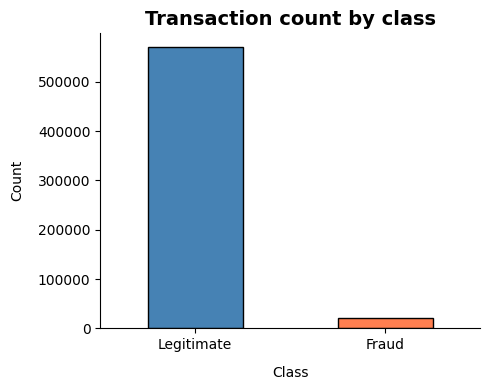

In [14]:
# Simple plot: number of transactions vs frauds (base rate visualization)
fig, ax = plt.subplots(figsize=(5, 4))
counts = train_full["isFraud"].value_counts().sort_index()
counts.index = ["Legitimate", "Fraud"]
counts.plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="black")
ax.set_title("Transaction count by class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Fraud rate by time window: quantile-based windows (qcut) for comparable observation counts
n_windows = 10
train_full["_time_bin"] = pd.qcut(train_full["TransactionDT"], q=n_windows, labels=False, duplicates="drop")

rate_by_time = train_full.groupby("_time_bin", observed=True).agg(
    total=("isFraud", "count"),
    fraud=("isFraud", "sum"),
).assign(rate=lambda x: x["fraud"] / x["total"])

print("Fraud rate by time window (qcut on TransactionDT):")
display(rate_by_time)

Fraud rate by time window (qcut on TransactionDT):


,total,fraud,rate
_time_bin,,,
0,59054,1631,0.027619
1,59054,1195,0.020236
2,59054,2200,0.037254
3,59054,2532,0.042876
4,59054,2336,0.039557
5,59054,2094,0.035459
6,59054,2550,0.043181
7,59054,2061,0.034900
8,59054,1851,0.031344


In [16]:
# Fraud rate by transaction amount bucket (quintiles)
train_full["_amt_bin"] = pd.qcut(train_full["TransactionAmt"], q=5, labels=["Q1(low)", "Q2", "Q3", "Q4", "Q5(high)"], duplicates="drop")

rate_by_amt = train_full.groupby("_amt_bin", observed=True).agg(
    total=("isFraud", "count"),
    fraud=("isFraud", "sum"),
).assign(rate=lambda x: x["fraud"] / x["total"])

print("Fraud rate by TransactionAmt quintile:")
display(rate_by_amt)

Fraud rate by TransactionAmt quintile:


,total,fraud,rate
_amt_bin,,,
Q1(low),121161,5302,0.043760
Q2,124763,3259,0.026122
Q3,122695,4060,0.033090
Q4,104478,2817,0.026963
Q5(high),117443,5225,0.044490


---
## 4. Confidence Intervals for Fraud Rate

Use Wilson score interval for binomial proportion (recommended for low rates and moderate n). CI bounds are computed for each time window and visualized as a shaded band in the temporal fraud rate plot (Section 7).

In [17]:
def wilson_ci(successes, n, alpha=0.05):
    """Wilson score interval for binomial proportion."""
    z = stats.norm.ppf(1 - alpha / 2)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - margin, center + margin

# Overall fraud rate with 95% CI
ci_low, ci_high = wilson_ci(fraud_count, n)
print("Overall fraud rate with 95% Wilson confidence interval:")
print(f"  Point estimate: {fraud_rate_overall:.4%}")
print(f"  95% CI: [{ci_low:.4%}, {ci_high:.4%}]")

Overall fraud rate with 95% Wilson confidence interval:
  Point estimate: 3.4990%
  95% CI: [3.4524%, 3.5462%]


In [18]:
# CI for each time window
rate_by_time["ci_low"] = rate_by_time.apply(lambda r: wilson_ci(int(r["fraud"]), int(r["total"]))[0], axis=1)
rate_by_time["ci_high"] = rate_by_time.apply(lambda r: wilson_ci(int(r["fraud"]), int(r["total"]))[1], axis=1)
print("Fraud rate by time window with 95% Wilson CI:")
display(rate_by_time)

Fraud rate by time window with 95% Wilson CI:


,total,fraud,rate,ci_low,ci_high
_time_bin,,,,,
0,59054,1631,0.027619,0.026327,0.028972
1,59054,1195,0.020236,0.019131,0.021403
2,59054,2200,0.037254,0.035756,0.038812
3,59054,2532,0.042876,0.041272,0.044540
4,59054,2336,0.039557,0.038015,0.041159
5,59054,2094,0.035459,0.033997,0.036981
6,59054,2550,0.043181,0.041571,0.044850
7,59054,2061,0.034900,0.033450,0.036411
8,59054,1851,0.031344,0.029969,0.032780


**Interpretation (base rate):** Fraud is rare (point estimate and 95% CI above). The margin of error of the estimate is half the CI width; at this sample size the uncertainty is small, so the base rate is estimated with good precision. This supports using the observed rate as a reference when comparing models.

---
## 5. Class Imbalance Analysis

**Objective:** Characterize the imbalance and justify cost-sensitive evaluation. Show proportion per class, ratio, and how this makes accuracy misleading (e.g. always predicting non-fraud yields high accuracy but misses all fraud). This justifies using **Expected Monetary Loss** as the primary metric (see `docs/03_metrics_and_cost_modeling.md`).

In [19]:
# Imbalance ratio: non-fraud / fraud
non_fraud_count = n - fraud_count
imbalance_ratio = non_fraud_count / fraud_count if fraud_count > 0 else np.nan

print("Class imbalance:")
print("  Fraud rate (%): {:.2f}%".format(fraud_rate_overall * 100))
print("  Imbalance ratio (non-fraud / fraud): {:.1f}:1".format(imbalance_ratio))
print("  Non-fraud: {:,} ({:.2%})".format(non_fraud_count, non_fraud_count / n))
print("  Fraud: {:,} ({:.2%})".format(int(fraud_count), fraud_rate_overall))
print("  Note: Always predicting non-fraud would give accuracy ~{:.1%} but 0% fraud detection.".format(non_fraud_count / n))

Class imbalance:
  Fraud rate (%): 3.50%
  Imbalance ratio (non-fraud / fraud): 27.6:1
  Non-fraud: 569,877 (96.50%)
  Fraud: 20,663 (3.50%)
  Note: Always predicting non-fraud would give accuracy ~96.5% but 0% fraud detection.


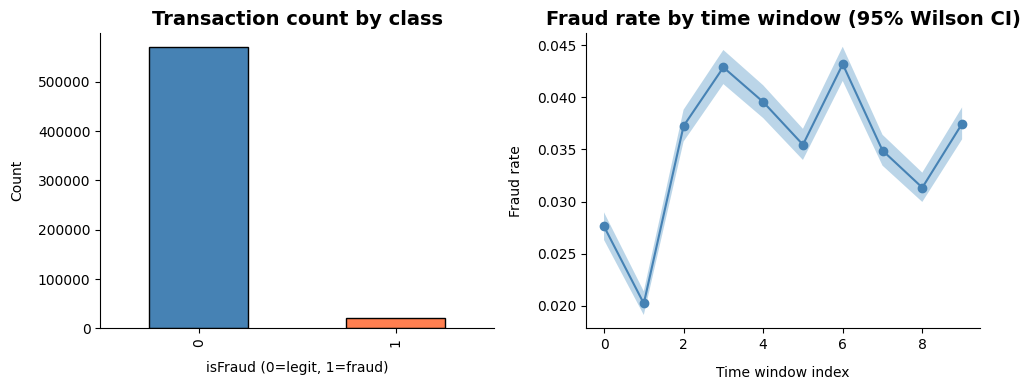

In [20]:
# Visualize fraud distribution: counts by class
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_full["isFraud"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["steelblue", "coral"], edgecolor="black")
axes[0].set_title("Transaction count by class")
axes[0].set_xlabel("isFraud (0=legit, 1=fraud)")
axes[0].set_ylabel("Count")

# Fraud rate over time windows (with CI)
x = rate_by_time.index
axes[1].fill_between(x, rate_by_time["ci_low"], rate_by_time["ci_high"], alpha=0.3)
axes[1].plot(x, rate_by_time["rate"], "o-", color="steelblue")
axes[1].set_title("Fraud rate by time window (95% Wilson CI)")
axes[1].set_xlabel("Time window index")
axes[1].set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

---
## 6. Transaction Amount Distribution (TransactionAmt)

**Objective:** Because fraud cost depends on `TransactionAmt` (C_FN = TransactionAmt), we need to understand this variable. Produce histogram or boxplot of transaction amount for legitimate vs fraudulent transactions; compare means and medians. This shows that fraud amounts can differ from legitimate ones and reinforces the cost logic of the system (see `03_metrics_and_cost_modeling.md`).

TransactionAmt by class (mean, median, count):


,Legitimate,Fraud
Mean,134.511665,149.244779
Median,68.500000,75.000000
Count,569877.000000,20663.000000


Mann-Whitney U test (fraud vs legitimate TransactionAmt): statistic = 5916827630.50, p-value = 0.2259
  -> Systematic difference in amount between classes supports cost-sensitive evaluation (C_FN = TransactionAmt).


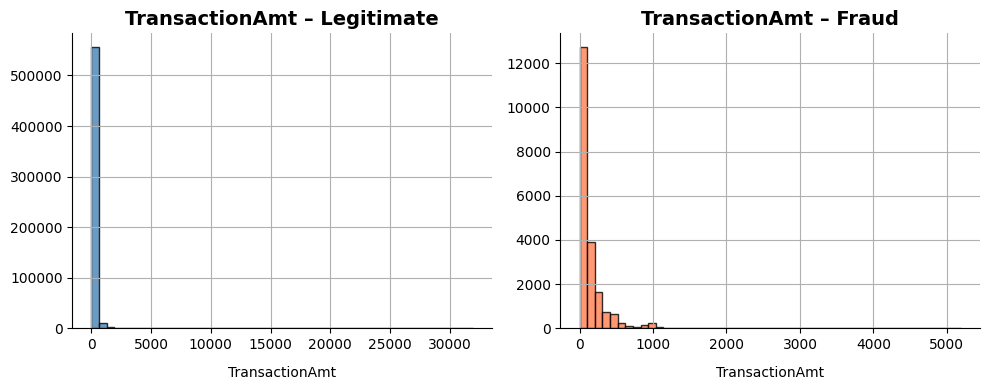

In [21]:
# TransactionAmt by class: summary stats and plot
legit_amt = train_full.loc[train_full["isFraud"] == 0, "TransactionAmt"]
fraud_amt = train_full.loc[train_full["isFraud"] == 1, "TransactionAmt"]

stats_amt = pd.DataFrame({
    "Legitimate": [legit_amt.mean(), legit_amt.median(), len(legit_amt)],
    "Fraud": [fraud_amt.mean(), fraud_amt.median(), len(fraud_amt)],
}, index=["Mean", "Median", "Count"])
print("TransactionAmt by class (mean, median, count):")
display(stats_amt)

# Statistical comparison: Mann-Whitney U (non-parametric)
mw_stat, mw_p = stats.mannwhitneyu(legit_amt, fraud_amt, alternative="two-sided")
print("Mann-Whitney U test (fraud vs legitimate TransactionAmt): statistic = {:.2f}, p-value = {:.4f}".format(mw_stat, mw_p))
print("  -> Systematic difference in amount between classes supports cost-sensitive evaluation (C_FN = TransactionAmt).")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
legit_amt.hist(ax=axes[0], bins=50, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("TransactionAmt – Legitimate")
axes[0].set_xlabel("TransactionAmt")
fraud_amt.hist(ax=axes[1], bins=50, color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("TransactionAmt – Fraud")
axes[1].set_xlabel("TransactionAmt")
plt.tight_layout()
plt.show()

---
## 7. Temporal Fraud Analysis

**Objective:** Aggregate by time window (TransactionDT), fraud rate per period, line plot. Detect if the rate is stable or varies over time; this **justifies temporal validation** in the project (see `05_modeling_strategy.md`). Compare first vs second half for a simple drift check.

In [22]:
# First vs last half of time span (simple drift check)
min_dt = train_full["TransactionDT"].min()
max_dt = train_full["TransactionDT"].max()
mid_dt = (min_dt + max_dt) / 2

first_half = train_full[train_full["TransactionDT"] < mid_dt]
second_half = train_full[train_full["TransactionDT"] >= mid_dt]

r1 = first_half["isFraud"].mean()
r2 = second_half["isFraud"].mean()
n1, n2 = len(first_half), len(second_half)
ci1 = wilson_ci(first_half["isFraud"].sum(), n1)
ci2 = wilson_ci(second_half["isFraud"].sum(), n2)

print("Temporal drift (first half vs second half of TransactionDT):")
print("  First half:  rate = {:.4%}, 95% CI = [{:.4%}, {:.4%}], n = {:,}".format(r1, ci1[0], ci1[1], n1))
print("  Second half: rate = {:.4%}, 95% CI = [{:.4%}, {:.4%}], n = {:,}".format(r2, ci2[0], ci2[1], n2))
abs_diff = r2 - r1
rel_diff = (r2 - r1) / r1 if r1 > 0 else np.nan
print("  Absolute difference (second - first): {:.4%}".format(abs_diff))
print("  Relative difference (vs first half rate): {:.2%}".format(rel_diff))
print("  (Effect size helps interpret practical impact; large n can make small differences significant.)")

Temporal drift (first half vs second half of TransactionDT):
  First half:  rate = 3.4014%, 95% CI = [3.3391%, 3.4648%], n = 319,927
  Second half: rate = 3.6144%, 95% CI = [3.5447%, 3.6854%], n = 270,613
  Absolute difference (second - first): 0.2130%
  Relative difference (vs first half rate): 6.26%
  (Effect size helps interpret practical impact; large n can make small differences significant.)


In [23]:
# Optional: test for proportion difference (two-sample z-test for proportions)
# H0: p1 = p2
p_pool = (first_half["isFraud"].sum() + second_half["isFraud"].sum()) / (n1 + n2)
se_diff = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z = (r2 - r1) / se_diff if se_diff > 0 else 0
p_value = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"  Two-proportion z-test p-value: {p_value:.4f}")

  Two-proportion z-test p-value: 0.0000


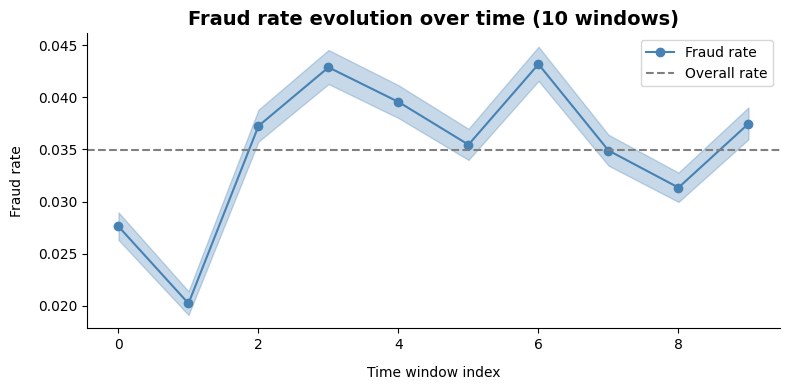

In [24]:
# Plot: fraud rate evolution over time windows (already computed in rate_by_time)
fig, ax = plt.subplots(figsize=(8, 4))
x = rate_by_time.index
ax.fill_between(x, rate_by_time["ci_low"], rate_by_time["ci_high"], alpha=0.3, color="steelblue")
ax.plot(x, rate_by_time["rate"], "o-", color="steelblue", label="Fraud rate")
ax.axhline(fraud_rate_overall, color="gray", linestyle="--", label="Overall rate")
ax.set_title("Fraud rate evolution over time (10 windows)")
ax.set_xlabel("Time window index")
ax.set_ylabel("Fraud rate")
ax.legend()
plt.tight_layout()
plt.show()

#### 7b. Rolling fraud rate

Rolling window average (e.g. 10k transactions) to identify gradual trends or regime shifts in fraud prevalence.

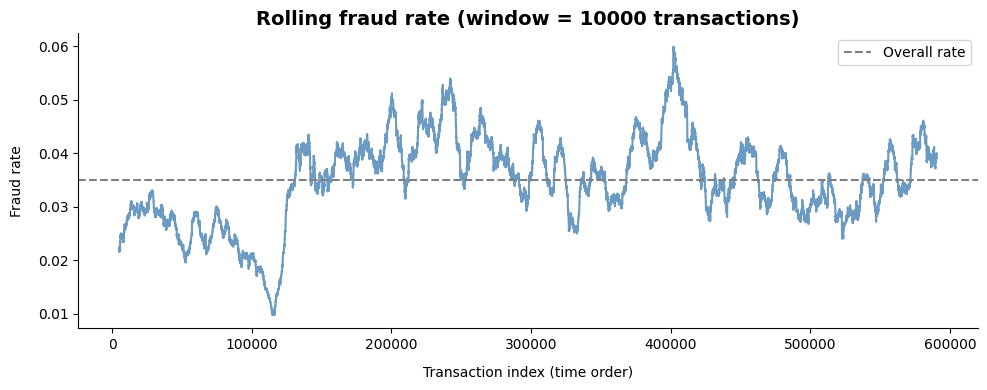

In [25]:
# Rolling fraud rate (window = 10k transactions, ordered by TransactionDT)
train_sorted = train_full.sort_values("TransactionDT").reset_index(drop=True)
window = 10_000
rolling_fraud = train_sorted["isFraud"].rolling(window=window, min_periods=window // 2).mean()
plt.figure(figsize=(10, 4))
plt.plot(rolling_fraud.values, color="steelblue", alpha=0.8)
plt.axhline(fraud_rate_overall, color="gray", linestyle="--", label="Overall rate")
plt.title("Rolling fraud rate (window = {} transactions)".format(window))
plt.xlabel("Transaction index (time order)")
plt.ylabel("Fraud rate")
plt.legend()
plt.tight_layout()
plt.show()

---
## 8. Feature-Level Temporal Drift

**Objective:** Compare first 30% vs last 30% of the time span. Add KS statistic and distribution plots for selected features. Rank features by drift magnitude (KS or mean diff/std) to identify those that change most over time.

In [26]:
# Feature-level drift: first 30% vs last 30% of time span (stronger drift check)
q30 = train_full["TransactionDT"].quantile(0.30)
q70 = train_full["TransactionDT"].quantile(0.70)
early = train_full[train_full["TransactionDT"] <= q30]
late = train_full[train_full["TransactionDT"] >= q70]
drift_amt_early = early["TransactionAmt"].agg(["mean", "median", "std"])
drift_amt_late = late["TransactionAmt"].agg(["mean", "median", "std"])
drift_compare = pd.DataFrame({"First 30%": drift_amt_early, "Last 30%": drift_amt_late})
print("TransactionAmt – first 30% vs last 30% of timeline:")
display(drift_compare)
# Kolmogorov-Smirnov test (distribution comparison)
ks_amt, p_ks_amt = stats.ks_2samp(early["TransactionAmt"], late["TransactionAmt"])
print("Kolmogorov-Smirnov (TransactionAmt, early vs late): statistic = {:.4f}, p-value = {:.4f}".format(ks_amt, p_ks_amt))
# Feature stability ranking: KS and mean diff / std
feat_drift = []
feat_drift.append({"feature": "TransactionAmt", "KS": ks_amt, "mean_diff": drift_amt_late["mean"] - drift_amt_early["mean"]})
if "card1" in train_full.columns and train_full["card1"].dtype in [np.int64, np.float64]:
    ks_card, _ = stats.ks_2samp(early["card1"].dropna(), late["card1"].dropna())
    m1, m2 = early["card1"].mean(), late["card1"].mean()
    feat_drift.append({"feature": "card1", "KS": ks_card, "mean_diff": m2 - m1})
drift_rank = pd.DataFrame(feat_drift).sort_values("KS", ascending=False)
print("Feature drift ranking (by KS statistic):")
display(drift_rank)

TransactionAmt – first 30% vs last 30% of timeline:


,First 30%,Last 30%
mean,129.748035,136.012508
median,75.000000,67.950000
std,207.270262,241.833494


Kolmogorov-Smirnov (TransactionAmt, early vs late): statistic = 0.0321, p-value = 0.0000
Feature drift ranking (by KS statistic):


,feature,KS,mean_diff
0,TransactionAmt,0.032078,6.264473
1,card1,0.016279,111.967290


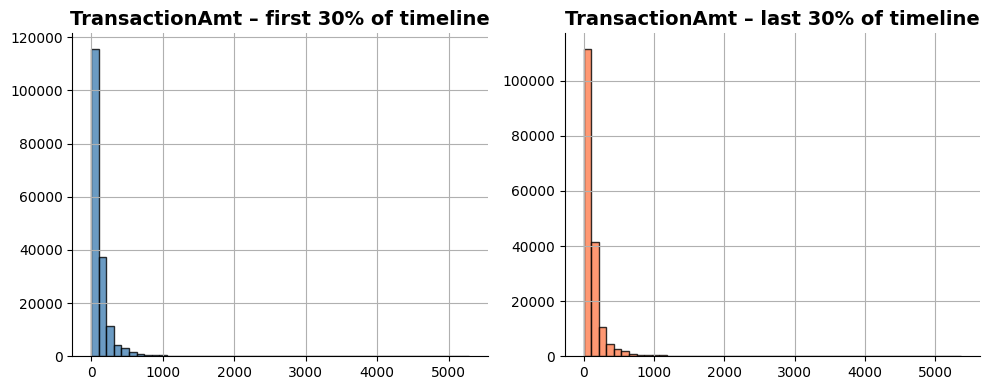

In [27]:
# Distribution comparison: TransactionAmt early vs late period
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
early["TransactionAmt"].hist(ax=axes[0], bins=50, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("TransactionAmt – first 30% of timeline")
late["TransactionAmt"].hist(ax=axes[1], bins=50, color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("TransactionAmt – last 30% of timeline")
plt.tight_layout(); plt.show()

---
## 9. Fraud Rate Variability by Segment

**Objective:** Split by **TransactionAmt quantile buckets (Q1–Q5)** — segmentation method is explicit and reproducible. Fraud rate per segment highlights where fraud risk is concentrated (risk concentration). This shows fraud is **not uniform** and may inform feature engineering.

Fraud rate by TransactionAmt quintile (Q1=low to Q5=high):


,total,fraud,rate
_amt_bin,,,
Q1(low),121161,5302,0.043760
Q2,124763,3259,0.026122
Q3,122695,4060,0.033090
Q4,104478,2817,0.026963
Q5(high),117443,5225,0.044490


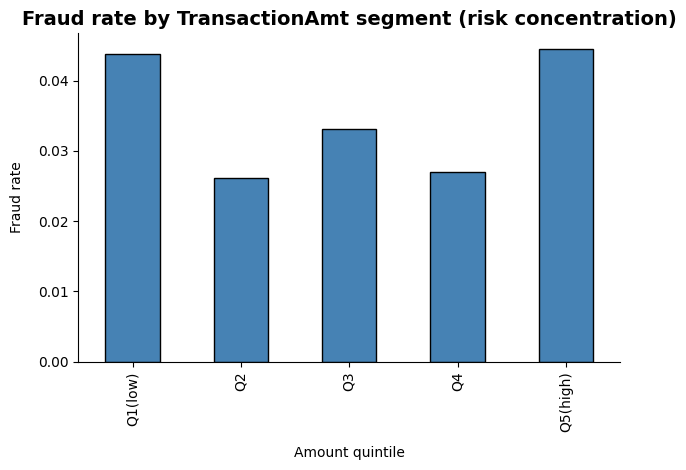

In [28]:
# Segment definition: TransactionAmt quantile buckets (Q1–Q5); rate_by_amt from Section 3
print("Fraud rate by TransactionAmt quintile (Q1=low to Q5=high):")
display(rate_by_amt)
rate_by_amt["rate"].plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Fraud rate by TransactionAmt segment (risk concentration)")
plt.xlabel("Amount quintile")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.show()

#### Optional: Bootstrap fraud rate & fraud rate by decile

**Bootstrap fraud rate:** Resampling to evaluate stability of the base rate estimate; **fraud rate by decile:** fraud prevalence across TransactionAmt deciles to reveal nonlinear relationships.

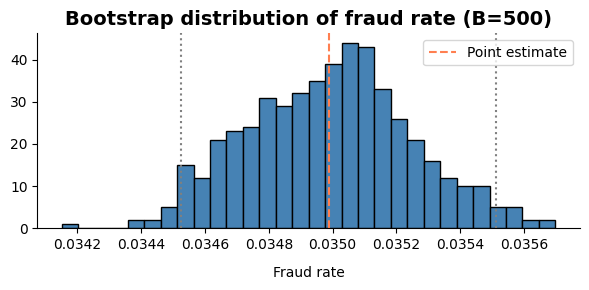

Bootstrap 95% CI for fraud rate: [3.4523%, 3.5511%]


In [29]:
# Optional: Bootstrap distribution of fraud rate (B=500)
B = 500
np.random.seed(42)
bootstrap_rates = np.array([train_full["isFraud"].sample(n=n, replace=True).mean() for _ in range(B)])
ci_boot = np.percentile(bootstrap_rates, [2.5, 97.5])
plt.figure(figsize=(6, 3))
plt.hist(bootstrap_rates, bins=30, color="steelblue", edgecolor="black")
plt.axvline(fraud_rate_overall, color="coral", linestyle="--", label="Point estimate")
plt.axvline(ci_boot[0], color="gray", linestyle=":"); plt.axvline(ci_boot[1], color="gray", linestyle=":")
plt.title("Bootstrap distribution of fraud rate (B={})".format(B))
plt.xlabel("Fraud rate"); plt.legend(); plt.tight_layout(); plt.show()
print("Bootstrap 95% CI for fraud rate: [{:.4%}, {:.4%}]".format(ci_boot[0], ci_boot[1]))

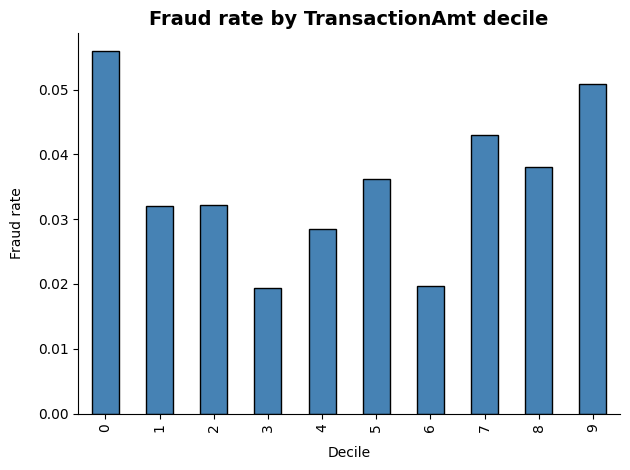

In [30]:
# Optional: Fraud rate by TransactionAmt decile (nonlinear relationship)
train_full["_amt_decile"] = pd.qcut(train_full["TransactionAmt"], q=10, labels=False, duplicates="drop")
rate_by_decile = train_full.groupby("_amt_decile", observed=True)["isFraud"].agg(["sum", "count"]).assign(rate=lambda x: x["sum"] / x["count"])
rate_by_decile["rate"].plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Fraud rate by TransactionAmt decile")
plt.xlabel("Decile"); plt.ylabel("Fraud rate"); plt.tight_layout(); plt.show()

---
## 10. Statistical Baseline for Model Comparison

Define how we will compare models statistically:
- **Primary metric:** Expected Monetary Loss (see `docs/03_metrics_and_cost_modeling.md`). Compare models on the same validation set at their respective cost-minimizing thresholds.
- **Uncertainty:** **Bootstrap is used to estimate the variability of Expected Monetary Loss** — model performance is subject to sampling variability; reporting CI for loss (and loss reduction) quantifies this uncertainty.
- **Discrimination:** ROC-AUC / PR-AUC as secondary; use bootstrap or DeLong test for comparing two ROC curves if needed.
- **Decision:** Prefer the model with lower Expected Loss; only claim improvement if the difference is meaningful and (optionally) supported by bootstrap CI (e.g. 95% CI for loss reduction does not include 0). When bootstrap is run in modeling notebooks, outputs should include a histogram of Expected Loss and its confidence interval.

In [31]:
# Bootstrap Expected Monetary Loss (example: we need predictions and C_FN, C_FP)
# This cell documents the methodology; actual bootstrap is run in modeling notebooks
# when we have two models to compare.

def expected_loss_one_sample(y_true, y_pred_binary, amt, c_fp=5.0):
    """Per-sample loss: FN cost = amt, FP cost = c_fp. Returns total loss."""
    fn_loss = ((y_true == 1) & (y_pred_binary == 0)) * amt
    fp_loss = ((y_true == 0) & (y_pred_binary == 1)) * c_fp
    return (fn_loss + fp_loss).sum()

# Bootstrap strategy (for use in model comparison):
# 1. Resample validation indices with replacement B times (e.g. B=500).
# 2. For each bootstrap sample, compute L(T*) and baseline loss; then loss reduction.
# 3. Report 2.5% and 97.5% quantiles as 95% CI for loss and for loss reduction.
# 4. If 95% CI for loss reduction is entirely > 0, we have evidence that the model beats baseline.

print("Bootstrap methodology for Expected Loss (to be applied in model_baseline or comparison notebooks):")
print("  - Resample validation set with replacement B=500.")
print("  - Compute L(T*) and baseline loss per bootstrap sample.")
print("  - 95% CI = [2.5%, 97.5%] quantiles of bootstrap distribution.")
print("  - Primary comparison: Expected Loss and Expected Loss Reduction.")

Bootstrap methodology for Expected Loss (to be applied in model_baseline or comparison notebooks):
  - Resample validation set with replacement B=500.
  - Compute L(T*) and baseline loss per bootstrap sample.
  - 95% CI = [2.5%, 97.5%] quantiles of bootstrap distribution.
  - Primary comparison: Expected Loss and Expected Loss Reduction.


---
## 11. Conclusion and Implications for Modeling

This phase answers three questions clearly:

1. **What is the fraud rate and its uncertainty?** — Point estimate and 95% Wilson CI; margin of error is small at this sample size.  
2. **How does the rate vary over time and across segments?** — Time windows and amount buckets show non-uniform fraud; temporal validation is justified; optional feature drift check (start vs end).  
3. **What are the statistical implications for evaluating models fairly?** — Primary metric is Expected Monetary Loss; bootstrap for uncertainty; only claim improvement when supported by evidence (e.g. 95% CI for loss reduction).

**Explicit modeling implications** (link to `docs/05_modeling_strategy.md`):
- **Temporal validation:** Fraud rate and feature distributions can change over time → train/validation split by `TransactionDT` is justified.  
- **Cost-sensitive evaluation:** Strong class imbalance and different TransactionAmt by class → use Expected Monetary Loss, not accuracy or F1 alone.  
- **Imbalance:** Imbalance ratio justifies `class_weight="balanced"` and threshold optimization by cost.  
- **Temporal drift:** If KS or first/last period stats differ, plan for monitoring and periodic retraining.

These conclusions form the analytical base for the next phase (Advanced Modeling & Calibration) and are summarized in `docs/06_statistical_diagnostics.md`.

---
## 12. Summary Table

Consolidate key diagnostics for documentation (`docs/06_statistical_diagnostics.md`).

In [32]:
# Expanded summary: fraud base rate, imbalance, temporal variation, avg TransactionAmt
temporal_rate_min = rate_by_time["rate"].min()
temporal_rate_max = rate_by_time["rate"].max()
avg_amt_legit = legit_amt.mean()
avg_amt_fraud = fraud_amt.mean()
summary = pd.DataFrame({
    "Metric": [
        "Total transactions",
        "Fraud count",
        "Fraud base rate",
        "95% CI (Wilson) lower",
        "95% CI (Wilson) upper",
        "Imbalance ratio (non-fraud:fraud)",
        "Temporal variation (min rate)",
        "Temporal variation (max rate)",
        "Avg TransactionAmt (legitimate)",
        "Avg TransactionAmt (fraud)",
        "Fraud rate first half",
        "Fraud rate second half",
        "Two-proportion z-test p-value",
    ],
    "Value": [
        f"{n:,}",
        f"{int(fraud_count):,}",
        f"{fraud_rate_overall:.4%}",
        f"{ci_low:.4%}",
        f"{ci_high:.4%}",
        f"{imbalance_ratio:.1f}:1",
        f"{temporal_rate_min:.4%}",
        f"{temporal_rate_max:.4%}",
        f"{avg_amt_legit:.2f}",
        f"{avg_amt_fraud:.2f}",
        f"{r1:.4%}",
        f"{r2:.4%}",
        f"{p_value:.4f}",
    ],
})
print("Statistical diagnostics summary")
display(summary)
print("Note: Expected loss baseline estimate is computed in model_baseline_v1.ipynb.")

Statistical diagnostics summary


,Metric,Value
0,Total transactions,"590,540"
1,Fraud count,"20,663"
2,Fraud base rate,3.4990%
3,95% CI (Wilson) lower,3.4524%
4,95% CI (Wilson) upper,3.5462%
5,Imbalance ratio (non-fraud:fraud),27.6:1
6,Temporal variation (min rate),2.0236%
7,Temporal variation (max rate),4.3181%
8,Avg TransactionAmt (legitimate),134.51
9,Avg TransactionAmt (fraud),149.24


Note: Expected loss baseline estimate is computed in model_baseline_v1.ipynb.
